# Exploratory Data Analysis — ChurnGuard
**Objectif** : Explorer les données brutes pour comprendre leur structure, 
détecter les anomalies et identifier les patterns liés au churn de la Banque.

**Dataset** : `churn_dataset_messy.csv`  
**Auteur** : Romaric TCHOFFO  
**Date** : 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

df  = pd.read_csv("../data/raw/churn_dataset_messy.csv")

print("import des modules et Dataset chargé")

import des modules et Dataset chargé


## 1.Aperçu général

In [2]:
df.head()

,ID,CustomerID,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,RegistrationDate,SatisfactionScore,NumComplaints,Email,Exited
0,111819,82197283105,Johnson,567.0,Germany,Homme,38,8.0,5234.53,2.0,1,1,0,2021-11-05,4,0.0,diane30@example.net,1
1,101210,36912803096,Lawrence,894.0,Spain,Male,54,3.0,13629.78,3.0,1,0,113027.18,2011-05-26,4,0.0,gordonosullivan@example.com,0
2,109466,97155583156,Chevalier,788.0,Spain,Male,40,9.0,17123.43,1.0,1,0,96117.51,2020-11-27,2,0.0,monniersylvie@example.org,0
3,104337,26159789757,Mülichen,608.0,Spain,Male,36,9.0,128278.02,1.0,1,1,81814.93,2015-10-28,4,2.0,derekstewart@example.org,0
4,112467,54492422739,Thomas,714.0,France,Male,25,1.0,7729.62,1.0,0,1,41672.29,2019-01-08,4,0.0,email@,0


In [3]:
df.shape

(15750, 18)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15750 entries, 0 to 15749
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 15750 non-null  int64  
 1   CustomerID         15750 non-null  int64  
 2   Surname            15658 non-null  object 
 3   CreditScore        15415 non-null  float64
 4   Geography          15594 non-null  object 
 5   Gender             15589 non-null  object 
 6   Age                15270 non-null  object 
 7   Tenure             15288 non-null  float64
 8   Balance            15321 non-null  object 
 9   NumOfProducts      15426 non-null  float64
 10  HasCrCard          15442 non-null  object 
 11  IsActiveMember     15266 non-null  object 
 12  EstimatedSalary    15333 non-null  object 
 13  RegistrationDate   15412 non-null  object 
 14  SatisfactionScore  15150 non-null  object 
 15  NumComplaints      15270 non-null  float64
 16  Email              152

In [5]:
df.dtypes.to_frame("Type").T

,ID,CustomerID,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,RegistrationDate,SatisfactionScore,NumComplaints,Email,Exited
Type,int64,int64,object,float64,object,object,object,float64,object,float64,object,object,object,object,object,float64,object,int64


## 2. Identification des variables

In [6]:
variables_continues = ["CreditScore","Age","Tenure","Balance","EstimatedSalary"]
variables_discretes = ["Surname","NumOfProducts","Email","SatisfactionScore","NumComplaints","RegistrationDate"]
variables_categorielles = ["Gender","Geography"]
variables_binaires = ["HasCrCard","IsActiveMember"]
variables_cibles = ["churn"]


print("Variables continues : ", variables_continues)
print("Variables discrètes : ", variables_discretes)
print("Variables catégorielles : ", variables_categorielles)
print("Variables binaires : ", variables_binaires)
print("Variable cible : ", variables_cibles)

Variables continues :  ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
Variables discrètes :  ['Surname', 'NumOfProducts', 'Email', 'SatisfactionScore', 'NumComplaints', 'RegistrationDate']
Variables catégorielles :  ['Gender', 'Geography']
Variables binaires :  ['HasCrCard', 'IsActiveMember']
Variable cible :  ['churn']


## 3. Qualité des données

In [7]:
(df.isna().sum()/len(df)*100).round(2).to_frame("% valeurs manquantes")

,% valeurs manquantes
ID,0.00
CustomerID,0.00
Surname,0.58
CreditScore,2.13
Geography,0.99
Gender,1.02
Age,3.05
Tenure,2.93
Balance,2.72
NumOfProducts,2.06


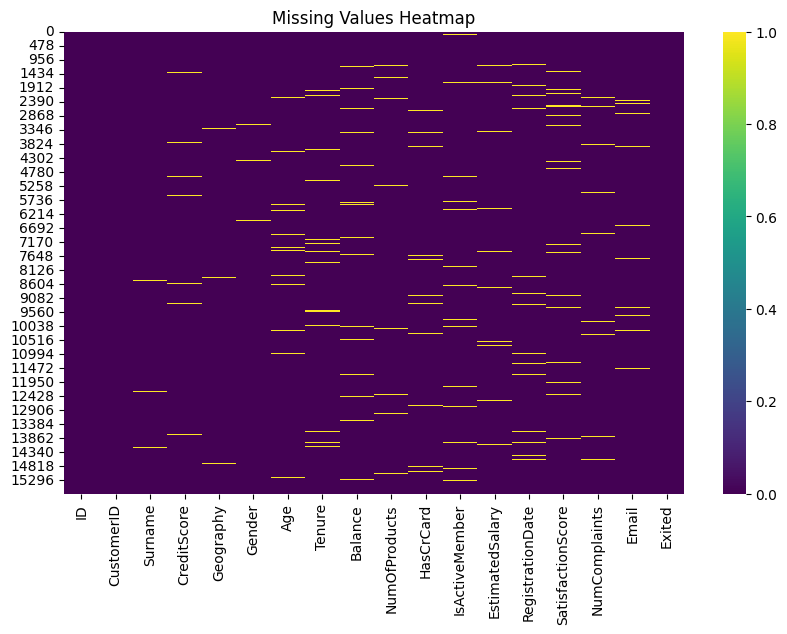

In [16]:
missing = df.isna()
plt.figure(figsize=(10,6))
sns.heatmap(missing, annot=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [9]:
df.duplicated().sum()

np.int64(750)

In [10]:
df.nunique().to_frame("Nombre de valeurs uniques")

,Nombre de valeurs uniques
ID,15000
CustomerID,15000
Surname,2358
CreditScore,611
Geography,9
Gender,11
Age,112
Tenure,13
Balance,14450
NumOfProducts,7


## 4. Analyse de la variable cible — Churn

In [11]:
df["Exited"].value_counts(normalize=True).to_frame("Proportion des clients ")

,Proportion des clients
Exited,
0,0.738667
1,0.261333


## 5. Distribution des variables continues univariés

count    15415.000000
mean       652.448784
std        128.524081
min        -50.000000
25%        582.000000
50%        651.000000
75%        719.000000
max       1500.000000
Name: CreditScore, dtype: float64


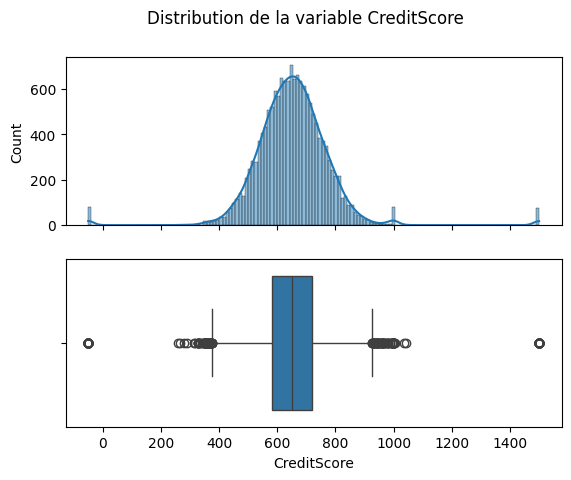

In [12]:
print(df["CreditScore"].describe())

fig, ax = plt.subplots(2,1 ,sharex=True)
plt.suptitle("Distribution de la variable CreditScore")
sns.histplot(df["CreditScore"], ax=ax[0], kde=True)
sns.boxplot(x=df["CreditScore"], ax=ax[1])
plt.show()

count     15270
unique      112
top          42
freq        518
Name: Age, dtype: object


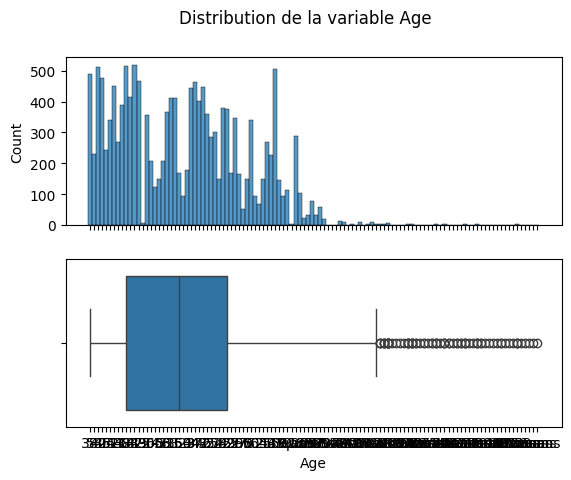

In [13]:
print(df["Age"].describe())
fig, ax = plt.subplots(2,1, sharex=True)
plt.suptitle("Distribution de la variable Age")
sns.histplot(df["Age"], ax=ax[0])
sns.boxplot(x=df["Age"], ax=ax[1])
plt.show()

count    15288.000000
mean         6.008569
std         10.349034
min         -1.000000
25%          2.000000
50%          5.000000
75%          8.000000
max        100.000000
Name: Tenure, dtype: float64


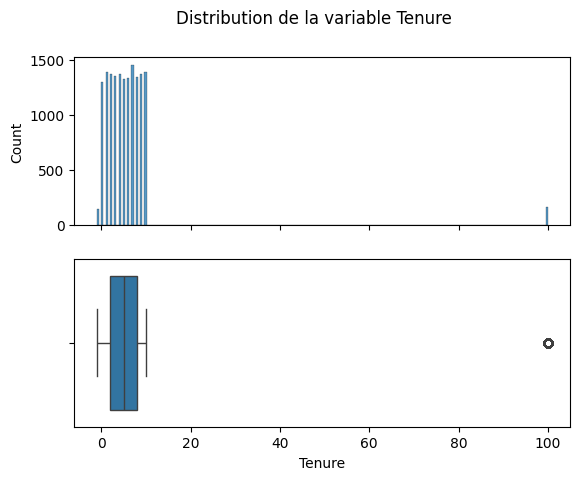

In [14]:
print(df["Tenure"].describe())

fig, ax = plt.subplots(2,1, sharex=True)
plt.suptitle("Distribution de la variable Tenure")
sns.histplot(df["Tenure"],ax=ax[0])
sns.boxplot(x=df["Tenure"], ax=ax[1])
plt.show()


count     15270
unique      112
top          42
freq        518
Name: Age, dtype: object


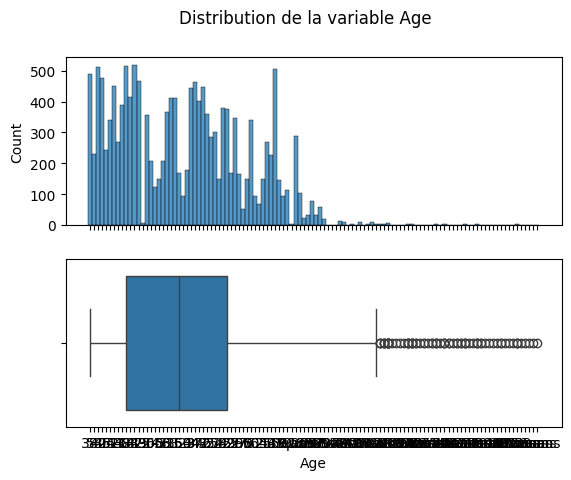

In [15]:
print(df["Age"].describe())

fig, ax = plt.subplots(2,1, sharex=True)
plt.suptitle("Distribution de la variable Age")
sns.histplot(df["Age"], ax=ax[0])
sns.boxplot(x=df["Age"], ax=ax[1])
plt.show()

## 6. Distribution des variables discrètes univariés
